Epoch 1/15 - Loss: 95.9120
Epoch 2/15 - Loss: 17.4308
Epoch 3/15 - Loss: 11.1154
Epoch 4/15 - Loss: 6.4757
Epoch 5/15 - Loss: 3.9414
Epoch 6/15 - Loss: 2.3414
Epoch 7/15 - Loss: 1.5744
Epoch 8/15 - Loss: 1.2925
Epoch 9/15 - Loss: 1.1221
Epoch 10/15 - Loss: 1.0688
Epoch 11/15 - Loss: 1.0398
Epoch 12/15 - Loss: 0.9896
Epoch 13/15 - Loss: 0.9696
Epoch 14/15 - Loss: 0.9604
Epoch 15/15 - Loss: 1.0269

Test MAE: 0.76, RMSE: 0.99


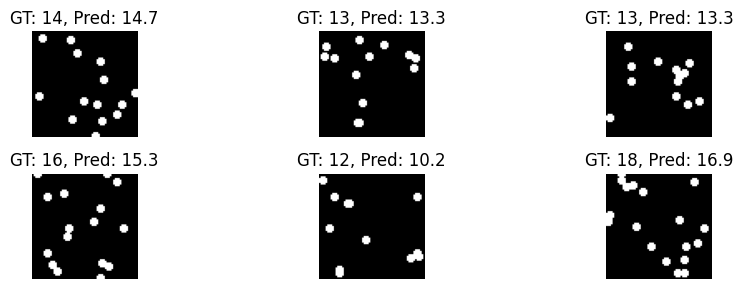

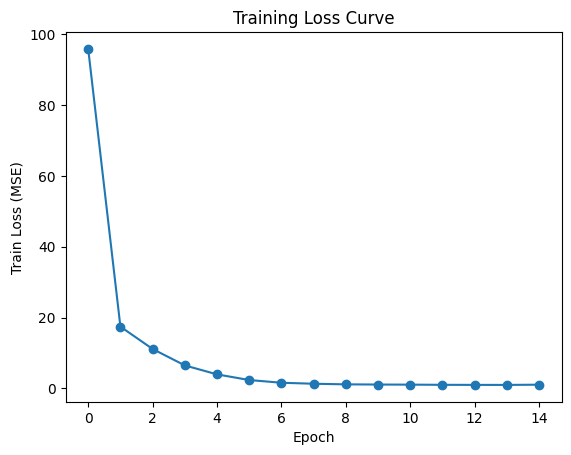

In [1]:
# ============================================================
# 🧮 Global Regression Counting with CNNs (PyTorch Tutorial)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from tqdm import tqdm

# -------------------------------
# 1️⃣ Synthetic counting dataset
# -------------------------------

class SyntheticCountDataset(Dataset):
    def __init__(self, n_images=500, img_size=64, max_dots=20, transform=None):
        self.n_images = n_images
        self.img_size = img_size
        self.max_dots = max_dots
        self.transform = transform

        self.data = []
        self.labels = []
        for _ in range(n_images):
            n = np.random.randint(0, max_dots + 1)
            img = Image.new("L", (img_size, img_size), 0)
            draw = ImageDraw.Draw(img)
            for _ in range(n):
                x, y = np.random.randint(0, img_size, 2)
                draw.ellipse((x-2, y-2, x+2, y+2), fill=255)
            self.data.append(img)
            self.labels.append(float(n))

    def __len__(self):
        return self.n_images

    def __getitem__(self, idx):
        img = self.data[idx]
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        if self.transform:
            img = self.transform(img)
        else:
            img = T.ToTensor()(img)
        return img, label

# -------------------------------
# 2️⃣ Create loaders
# -------------------------------

transform = T.Compose([
    T.ToTensor(),
])

train_ds = SyntheticCountDataset(n_images=400, transform=transform)
test_ds  = SyntheticCountDataset(n_images=100, transform=transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=16)

# -------------------------------
# 3️⃣ Simple CNN regressor
# -------------------------------

class CountRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        x = self.net(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x.squeeze(1)

# -------------------------------
# 4️⃣ Training loop
# -------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CountRegressor().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 15
train_losses = []

for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs)
        loss = criterion(preds, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    epoch_loss = total_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{n_epochs} - Loss: {epoch_loss:.4f}")

# -------------------------------
# 5️⃣ Evaluation
# -------------------------------

model.eval()
mae, mse, count = 0, 0, 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs)
        mae += (preds - labels).abs().sum().item()
        mse += ((preds - labels)**2).sum().item()
        count += imgs.size(0)

print(f"\nTest MAE: {mae/count:.2f}, RMSE: {(mse/count)**0.5:.2f}")

# -------------------------------
# 6️⃣ Visualization
# -------------------------------

model.eval()
imgs, labels = next(iter(test_loader))
preds = model(imgs.to(device)).cpu().detach().numpy()

plt.figure(figsize=(10, 3))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(imgs[i][0], cmap="gray")
    plt.title(f"GT: {labels[i]:.0f}, Pred: {preds[i]:.1f}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# -------------------------------
# 7️⃣ Plot loss curve
# -------------------------------
plt.figure()
plt.plot(train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Train Loss (MSE)")
plt.title("Training Loss Curve")
plt.show()
